In [14]:
import sys
import csv
import os
import regex as re
import numpy as np

# /workspaces/collaborative-scene-graphs/metrics/2025-02-19T14:35-OG-completed
# /workspaces/collaborative-scene-graphs/metrics/2025-02-19T19:50-MaskCLIP-completed
eval_sessions = '''
/workspaces/collaborative-scene-graphs/metrics/2025-02-19T23:58
'''.strip().split('\n')

eval_runs = []
n_sessions = len(eval_sessions)
seqs = []
for session in eval_sessions:
    runs = os.listdir(session)
    for run in runs:
        # parse metrics/2025-02-15T19:58-completed/agents-12_remove_dyn_objs-True
        if run != "agents-012_remove_dyn_objs-False":
            continue

        match = re.match(r'agents-(\d+)_remove_dyn_objs-(True|False)', run)
        if match is None:
            continue
        agents, rdo = match.groups()

        d = os.path.join(session, run)
        with open(d + '/kitti.csv', 'r') as f:
            reader = csv.DictReader(f)
            seq = {
                "remove_dyn": rdo == "True",
                "n_agents": len(agents),
                "metrics": list(reader),
            }
            # read floats
            seq["metrics"] = [{k: float(v) for k,v in m.items()} for m in seq["metrics"]]
            seq["metrics"].sort(key=lambda x: x["timestamp"])
            if len(seq["metrics"]) < 10:
                continue
            seqs.append(seq)
        

seqs


[{'remove_dyn': False,
  'n_agents': 3,
  'metrics': [{'timestamp': 29.969890952,
    'mean_transl_err': 1.8976413011550903,
    'std_transl_err': 0.19071927666664124,
    'mean_rot_err': 0.008642738685011864,
    'std_rot_err': 0.0013311729999259114},
   {'timestamp': 35.023194074,
    'mean_transl_err': 2.659630537033081,
    'std_transl_err': 1.0458006858825684,
    'mean_rot_err': 0.010838610120117664,
    'std_rot_err': 0.007497875019907951},
   {'timestamp': 39.974114656,
    'mean_transl_err': 2.291102409362793,
    'std_transl_err': 0.905311107635498,
    'mean_rot_err': 0.009214290417730808,
    'std_rot_err': 0.005712884943932295},
   {'timestamp': 44.976513504,
    'mean_transl_err': 2.1371819972991943,
    'std_transl_err': 0.827756941318512,
    'mean_rot_err': 0.008926869370043278,
    'std_rot_err': 0.004740417469292879},
   {'timestamp': 49.978564739,
    'mean_transl_err': 2.260939359664917,
    'std_transl_err': 0.8208757042884827,
    'mean_rot_err': 0.00959401763975

In [15]:
# find the earliest end stamp
end_stamp = min([float(seq["metrics"][-1]["timestamp"]) for seq in seqs])

# cut each sequence to end at the end_stamp
for seq in seqs:
    seq["metrics"] = list(filter(lambda x: float(x["timestamp"]) <= end_stamp, seq["metrics"]))


In [16]:
x = np.linspace(0, end_stamp, 1000)

# compute gradient with numpy
for seq in seqs:
    xp = np.array([m["timestamp"] for m in seq["metrics"]])
    fp = np.array([m["mean_transl_err"] for m in seq["metrics"]])
    ate_interp = np.interp(x, xp, fp)
    seq["ate_interp"] = ate_interp

    grad = np.gradient(seq["ate_interp"])

    # find the first index where the gradient is below -100
    idx = np.argmax(grad < -50)
    seq["ate_interp"][:idx+10] = np.nan

In [17]:
max_n_agents = max([seq["n_agents"] for seq in seqs])

mean_ate_by_n_agents = np.zeros((max_n_agents, 1000))
for n_agents in range(max_n_agents):
    seqs_n_agents = list(filter(lambda x: x["n_agents"] == n_agents + 1, seqs))
    if len(seqs_n_agents) == 0:
        continue
    mean_ate_by_n_agents[n_agents] = np.mean([seq["ate_interp"] for seq in seqs_n_agents], axis=0)
    

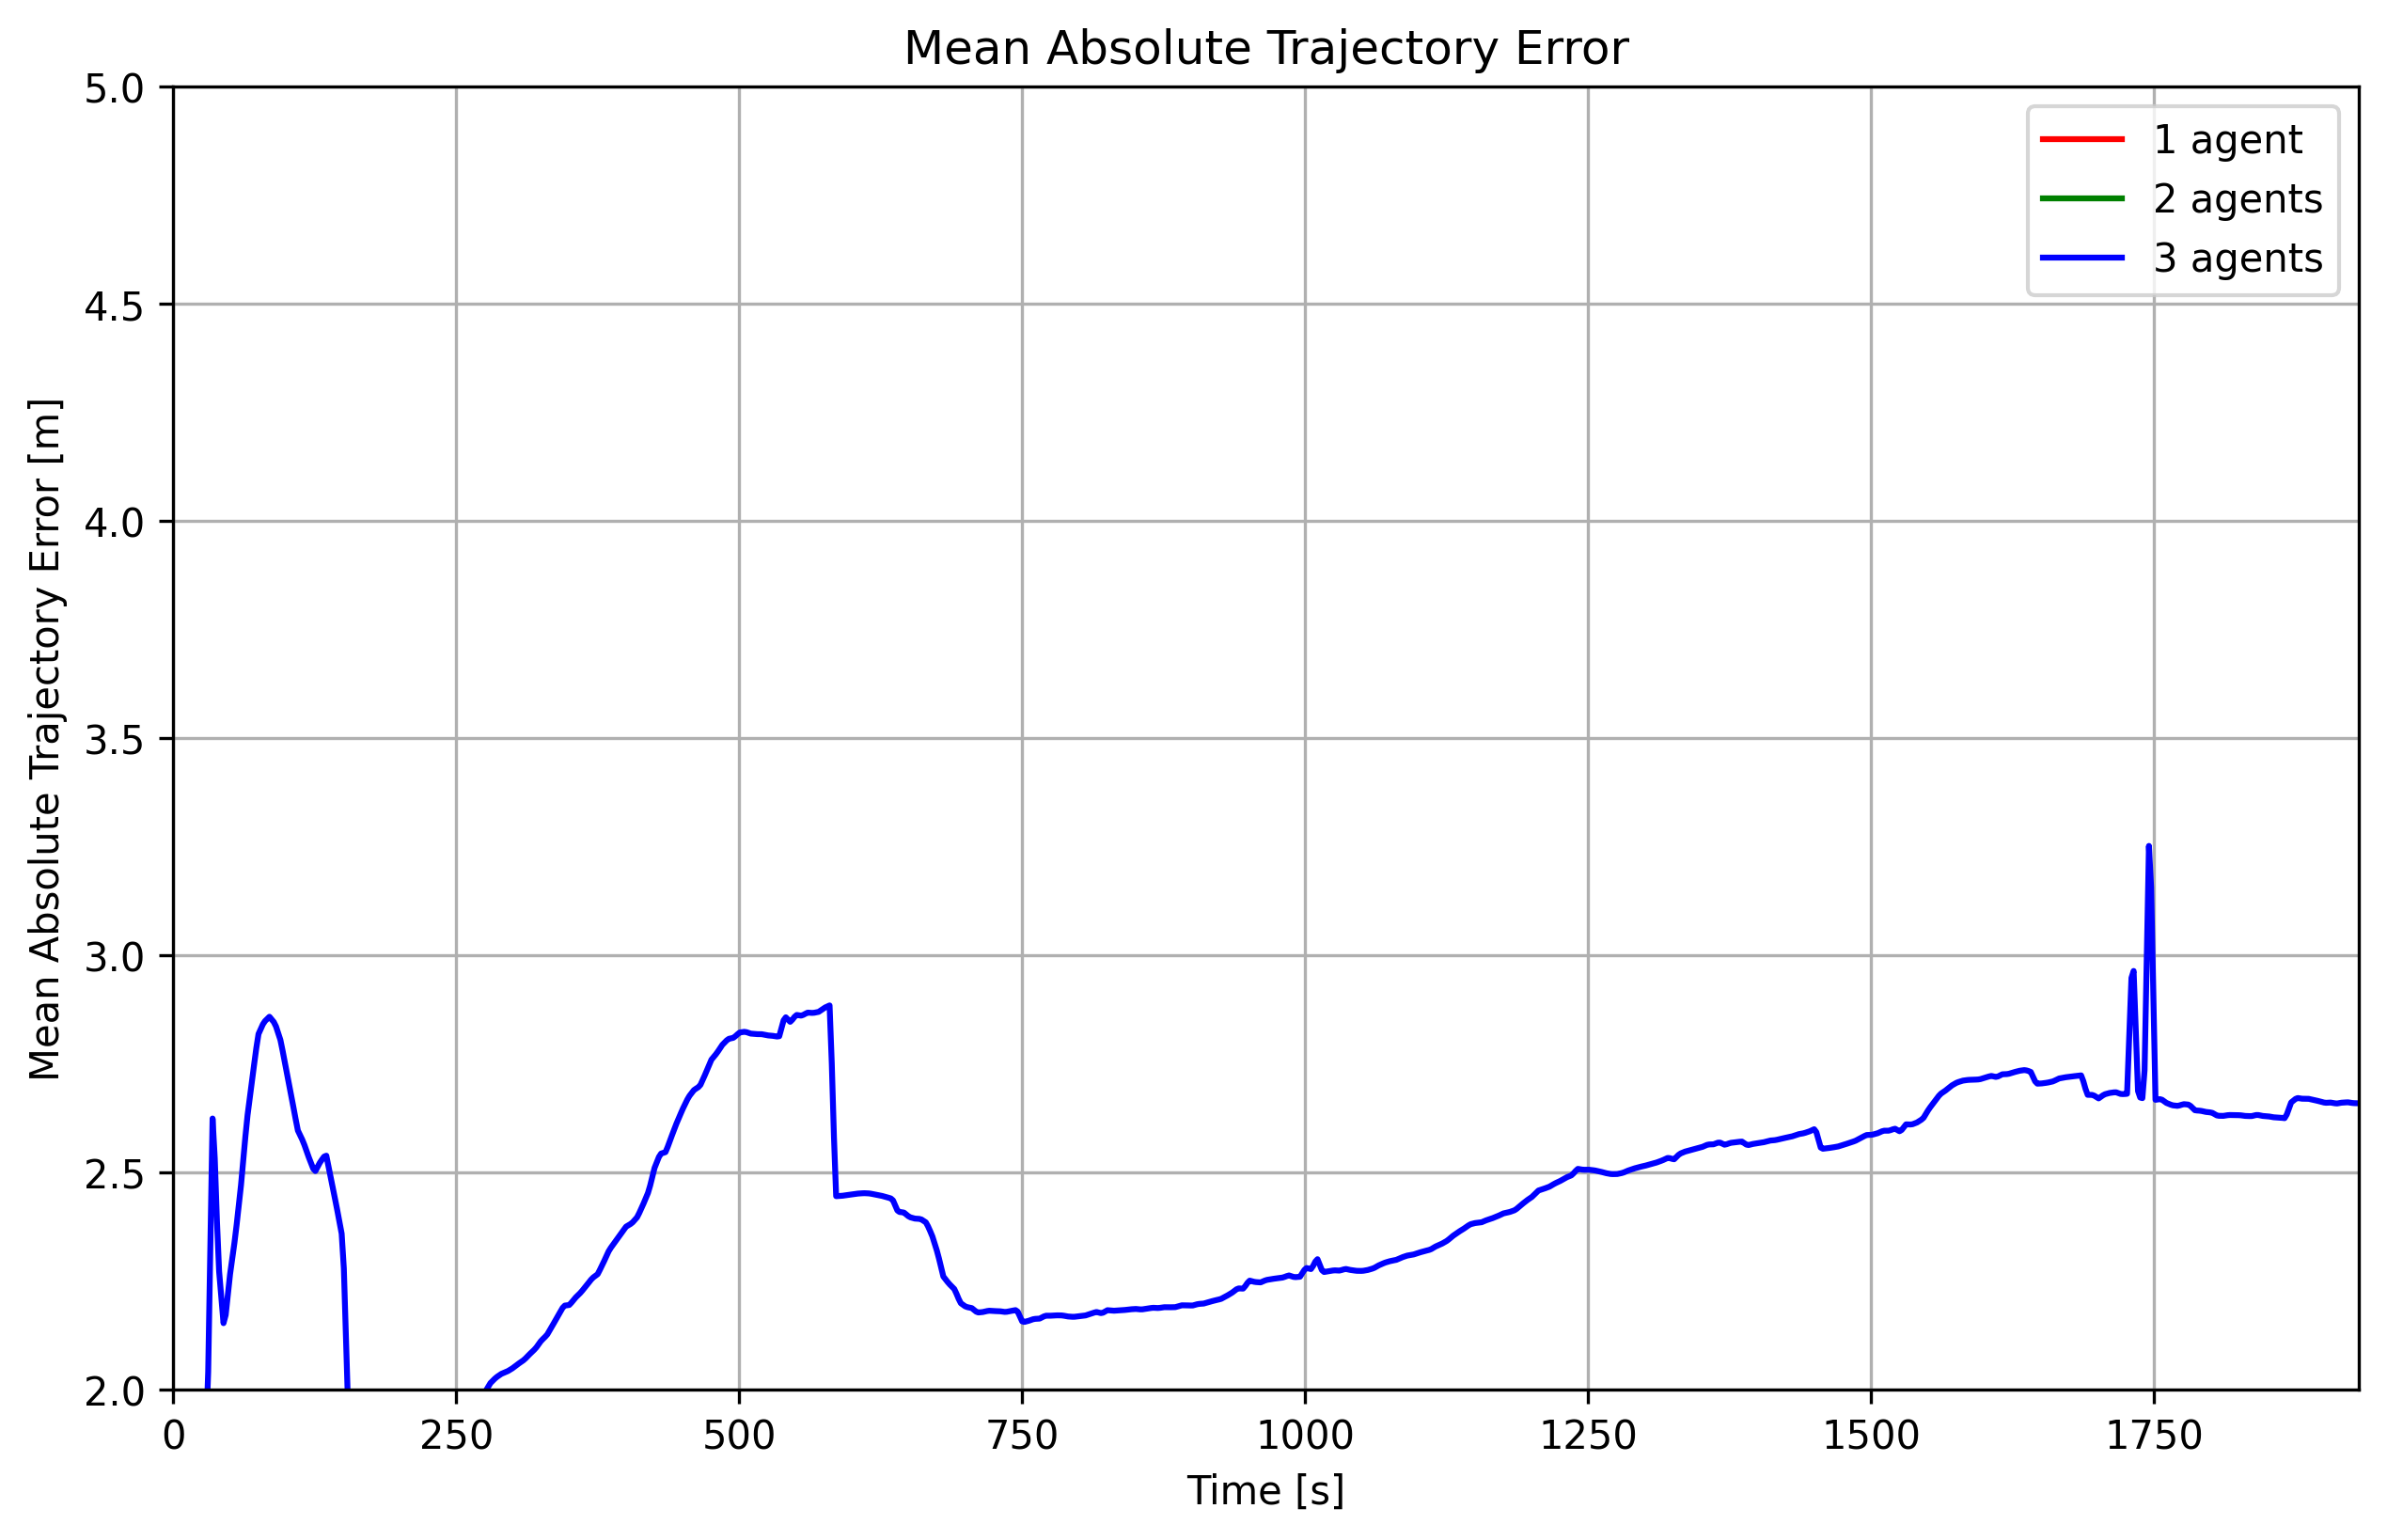

In [18]:
import matplotlib.pyplot as plt

# Render a matplotlib plot with all three agents mean ATE and std uncertainty areas
plt.figure(figsize=(10, 6))
# increase dpi
plt.rcParams['figure.dpi'] = 300

colors = ['red', 'green', 'blue']

for seq in seqs:
    y = seq["ate_interp"]
    
    # linestyle = 'dashed' if not seq["remove_dyn"] else 'dotted'
    linestyle='solid'
    label = f'{seq["n_agents"]} agent{"s" if seq["n_agents"] > 1 else ""} (dyn. points {"" if seq["remove_dyn"] else "not"} removed)'
    plt.plot(x, y, label=label, color=colors[seq["n_agents"]-1], linestyle=linestyle, alpha=0.1, linewidth=1.0)

for n_agents in range(max_n_agents):
    y = mean_ate_by_n_agents[n_agents]
    plt.plot(x, y, label=f'{n_agents + 1} agents', color=colors[n_agents], linestyle='solid', linewidth=1.5, alpha=1.0)
    
plt.xlabel('Time [s]')
plt.ylabel('Mean Absolute Trajectory Error [m]')
plt.legend()
# cut negative values
plt.ylim(bottom=2)
# plt.ylim(top=max(max(mate_0), max(mate_1), max(mate_2)) + 10)
plt.ylim(top=5)
plt.xlim(left=0)
plt.xlim(right=end_stamp)
plt.title('Mean Absolute Trajectory Error')

# make custom legend distinguishing dashed/solid and colors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

handles = [
    # mlines.Line2D([], [], color='black', linestyle='solid', label='Dynamic points removed'),
    # mlines.Line2D([], [], color='black', linestyle='dashed', label='Dynamic points not removed'),
    mlines.Line2D([], [], color='red', linestyle='solid', label='1 agent'),
    mlines.Line2D([], [], color='green', linestyle='solid', label='2 agents'),
    mlines.Line2D([], [], color='blue', linestyle='solid', label='3 agents'),
]
plt.legend(handles=handles)

plt.grid()

plt.show()
